# **Project 3 − A Galton Board on a Rocking Ship**
## Advanced Simulation and Machine Learning | TIF345
## Chalmers University of Technology | Fall 2025
---
### Linus Brink | [brinkl@chalmers.se](mailto:brinkl@chalmers.se) 
### Oscar Stommendal | [oscarsto@chalmers.se](mailto:oscarsto@chalmers.se)
---

## **Setup**

In [922]:

# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from tqdm import tqdm
import seaborn as sns

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Latex plotting settings
plt.rc('text', usetex = True)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'palatino'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{bm}'
font_size = 14
plt.rcParams['font.size'] = font_size
plt.rcParams['xtick.labelsize'] = font_size
plt.rcParams['ytick.labelsize'] = font_size
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# General functions
def joint_plotter(s_samples, alpha_samples, s_mean, s_std, alpha_mean, alpha_std, weights, cmap, truth_color, mean_color, n_bins, ax=None, figsize=(5, 3), broken=False):
    # Create figure and axis if not provided
    if ax is None:
        fig = plt.figure(figsize=figsize)
        if not broken:
            ax = fig.gca()
    else:
        fig = plt.gcf()

    # Plot joint distribution, with broken axes if specified
    if broken:
        ax1 = fig.add_axes([0.123, 0.55, 0.5, 0.32]) # Top side axes
        ax2 = fig.add_axes([0.123, 0.21, 0.5, 0.32]) # Bottom side axes
        ax1.grid(True, linestyle='-', alpha=0.5)
        ax2.grid(True, linestyle='-', alpha=0.5)

        # Plot bars
        sns.histplot(x=alpha_samples, y=s_samples, bins=50, stat='density', cmap=cmap, cbar=False, ax=ax1)
        ax1.axvline(x=0.25, color=truth_color, linestyle='-', linewidth=2)
        ax2.axvline(x=0.25, color=truth_color, linestyle='-', linewidth=2)
        ax2.axhline(y=0.1, color=truth_color, linestyle='-', linewidth=2)
        ax2.plot(0.25, 0.1, color=truth_color, marker='o', fillstyle='none', markersize=12, markeredgewidth=2, label='True value', linewidth=2)

        # Set x-limits
        ax1.set_xlim(alpha_samples.min() - 0.01, alpha_samples.max() + 0.01)
        ax2.set_xlim(alpha_samples.min() - 0.01, alpha_samples.max() + 0.01)
        ax1.set_xticklabels([])
        ax2.set_ylim(0.099, 0.102)
        ax2.set_yticks([0.1, 0.101])

        # Hide spines between subplots
        ax1.spines.bottom.set_visible(False)
        ax2.spines.top.set_visible(False)
        ax1.tick_params(bottom=False)
        ax2.tick_params(top=False)

        # Diagonal break marks
        d = 0.02 # Size of diagonal lines
        kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
        ax1.plot((-d, +d), (-d, +d), **kwargs)
        ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
        kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False)
        ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
        ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
        ax = (ax1, ax2)
        ax2.text(0.14, 0.102, r'$s$', rotation=90)

        # For labels and legends
        ax2.plot([], [], color=mean_color, linestyle='-', linewidth=2, label='Posterior mean')
        ax2.plot([], [], color=mean_color, linestyle='--', linewidth=2, label=r'$\pm 1\sigma$')
        ax2.set_xlabel(r'$\alpha$')

    else:
        sns.histplot(x=alpha_samples, y=s_samples, bins=50, stat='density', cmap=cmap, cbar_kws={'label': 'Density', 'location': 'bottom', 'pad': 0.07})
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(direction='out', length=5, width=1)
        plt.axvline(x=0.25, color=truth_color, linestyle='-', linewidth=2)
        plt.axhline(y=0.1, color=truth_color, linestyle='-', linewidth=2)
        plt.plot(0.25, 0.1, color=truth_color, marker='o', fillstyle='none', markersize=12, markeredgewidth=2, label='True value', linewidth=2)
        plt.xlim(0, 0.5)
        # plt.ylim(-0.25, 0.25)
        plt.xlabel(r'$\alpha$')
        plt.ylabel(r'$s$')

    # Plot histograms on the top (same for both broken and unbroken)
    ax_top = fig.add_axes([0.125, 0.915, 0.77, 0.15])
    # ax_top = fig.add_axes([0.123, 0.915, 0.5, 0.15])
    ax_top.hist(alpha_samples, bins=n_bins[0], density=True, color='turquoise', edgecolor='black', alpha=0.8)

    # Hide top, left, and right spines
    ax_top.spines['top'].set_visible(False)
    ax_top.spines['right'].set_visible(False)
    ax_top.spines['left'].set_visible(False)
    ax_top.tick_params(direction='out', length=5, width=1)
    ax_top.tick_params(left=False)
    ax_top.set_yticklabels([])
    ax_top.set_xticklabels([])

    # Draw lines for true value, mean, and std
    ax_top.axvline(x=0.25, color=truth_color, linestyle='-', linewidth=2)
    ax_top.axvline(x=alpha_mean, color=mean_color, linestyle='-', linewidth=2)
    ax_top.axvline(x=alpha_mean + alpha_std, color=mean_color, linestyle='--', linewidth=2)
    ax_top.axvline(x=alpha_mean - alpha_std, color=mean_color, linestyle='--', linewidth=2)
    ax_top.set_xlim(0, 0.5)

    # Plot histograms on the right (different for broken and unbroken)
    if not broken:
        ax_right = fig.add_axes([0.94, 0.11, 0.1, 0.77])
        ax_right.hist(s_samples, bins=n_bins[1], density=True, color='turquoise', edgecolor='black', alpha=0.8, orientation='horizontal')
        ax_right.spines['top'].set_visible(False)
        ax_right.spines['right'].set_visible(False)
        ax_right.spines['bottom'].set_visible(False)
        ax_right.tick_params(direction='out', length=5, width=1)
        ax_right.tick_params(bottom=False)
        ax_right.set_yticklabels([])
        ax_right.set_xticklabels([])
        ax_right.axhline(y=0.1, color=truth_color, linestyle='-', linewidth=2)
        ax_right.axhline(y=s_mean, color=mean_color, linestyle='-', linewidth=2)
        ax_right.axhline(y=s_mean + s_std, color=mean_color, linestyle='--', linewidth=2)
        ax_right.axhline(y=s_mean - s_std, color=mean_color, linestyle='--', linewidth=2)
        # ax_right.set_ylim(-0.25, 0.25)
    else:
        ax_top.set_xlim(alpha_samples.min() - 0.01, alpha_samples.max() + 0.01)
        ax_right = fig.add_axes([0.65, 0.55, 0.1, 0.32])
        ax_right.hist(s_samples, bins=n_bins[1], density=True, color='turquoise', edgecolor='black', alpha=0.8, orientation='horizontal')
        ax_right.spines['top'].set_visible(False)
        ax_right.spines['right'].set_visible(False)
        ax_right.spines['bottom'].set_visible(False)
        ax_right.tick_params(direction='out', length=5, width=1)
        ax_right.tick_params(bottom=False)
        ax_right.set_yticklabels([])
        ax_right.set_xticklabels([])
        ax_right.axhline(y=s_mean, color=mean_color, linestyle='-', linewidth=2)
        ax_right.axhline(y=s_mean + s_std, color=mean_color, linestyle='--', linewidth=2)
        ax_right.axhline(y=s_mean - s_std, color=mean_color, linestyle='--', linewidth=2)
        # ax_right.set_ylim(-0.25, 0.25)
        ax_right_2 = fig.add_axes([0.65, 0.21, 0.1, 0.32])
        ax_right_2.spines['top'].set_visible(False)
        ax_right_2.spines['right'].set_visible(False)
        ax_right_2.spines['bottom'].set_visible(False)
        ax_right_2.tick_params(direction='out', length=5, width=1)
        ax_right_2.tick_params(bottom=False)
        ax_right_2.set_yticklabels([])
        ax_right_2.set_xticklabels([])
        ax_right_2.set_ylim(0.099, 0.102)
        ax_right_2.set_yticks([0.1, 0.101])
        ax_right_2.axhline(y=0.1, color=truth_color, linestyle='-', linewidth=2)

    # Legends
    if not broken:
        ax.plot([], [], color=mean_color, linestyle='-', linewidth=2, label='Posterior mean')
        ax.plot([], [], color=mean_color, linestyle='--', linewidth=2, label=r'Posterior $\pm 1\sigma$')
        ax.legend(fontsize=12)
    else:
        ax2.legend(fontsize=12)
    
    return fig, ax

def dist_data_plotter(ax, true_counts, simulated_counts, simulated_counts_std, n_cols):
    
    # Plot bars for true and simulated data and shaded area for std
    sns.barplot(x=np.arange(len(true_counts)), y=true_counts, color='k', alpha=0.8, label='Observed data', ax=ax)
    sns.barplot(x=np.arange(len(simulated_counts)), y=simulated_counts, color='turquoise', alpha=0.7, label='Simulated data', ax=ax)
    ax.fill_between(np.arange(len(simulated_counts)), simulated_counts - simulated_counts_std, simulated_counts + simulated_counts_std, color='darkslateblue', alpha=0.3, label=r'Simulated $\pm 1\sigma$')
    
    # Axes settings
    ax.set_xticks(np.arange(0, n_cols, 5))
    ax.set_xlabel('Trench index')
    ax.set_ylabel('Number of beads')
    handles, labels = ax.get_legend_handles_labels()

    order = [
        labels.index('Observed data'),
        labels.index('Simulated data'),
        labels.index(r'Simulated $\pm 1\sigma$')
    ]

    ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        fontsize=12
    )
    ax.grid(True, linestyle='-', alpha=0.5)

    return ax


## **Data Collection and Parameter Definitions**

In [ ]:

# Read data
data_file = 'data/board_data.npy'
board_data = np.load(data_file)

# Retrieve the board parameters
n_trials = board_data.shape[0]
n_cols = board_data.shape[1]
n_rows = board_data.shape[1] - 1
n_beads = int(np.sum(board_data[0]))

print(f'Number of experiments: {n_trials}')
print(f'Galton board with {n_rows} rows and {n_cols} columns, total number of beads: {n_beads:.0f}')


Number of experiments: 10000
Galton board with 31 rows and 32 columns, total number of beads: 1000


## **General Dalton Simulator**

In [ ]:

def dalton_probability_model(M, alpha, s):
    '''
    Model for the Dalton board.

    Args:
        M (float): Previous bounce parameter, 0 at entrance, -0.5 if bounced left last time, +0.5 if bounced right last time,
        alpha (float): Bias parameter,
        s (float): Rocking parameter describing tilt of the rocking ship.

    Returns:
        prob_right (float): Probability of bouncing right,
        prob_left (float): Probability of bouncing left.
    '''

    prob_right = 0.5 + (alpha * M + s)
    prob_left = 0.5 - (alpha * M + s)

    return prob_right, prob_left

def vec_dalton_simulator(n_rows, n_cols, n_beads, alpha, s, disable=False, seed=False):
    '''
    Simulator for the Dalton board on a rocking ship.

    Args:
        n_rows (int): Number of rows,
        n_cols (int): Number of columns,
        n_beads (int): Number of beads to simulate,
        alpha (float): Bias parameter,
        s (float): Rocking parameter describing tilt of the rocking ship.
    
    Returns:
        trench_positions (ndarray): The number of beads in each trench.
    '''

    positions = np.zeros(n_beads) + ((n_cols + n_rows) // 2) # Starting positions for all beads (middle peg)
    M = np.zeros(n_beads)  # Previous bounce parameters for all beads

    p0_R = 0.5 + s # Probability of going right at first peg
    p_R_R = 0.5 + alpha * 0.5 + s # Probability of going right if previous was right
    p_R_L = 0.5 - alpha * 0.5 + s # Probability of going right if previous was left
    if seed:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()

    # Simulate all beads through all rows
    for _ in tqdm(range(n_rows), desc='Simulating Dalton board (vectorized)', disable=disable):
        probs_right = np.where(M == 0, p0_R, np.where(M == 0.5, p_R_R, p_R_L)) # Probabilities of going right for all beads

        moves = rng.random(size=n_beads) < probs_right  # True for right, False for left
        moves = np.where(moves, 1, -1) # Convert to +1 (right) and -1 (left)

        positions += moves # Update positions

        M = np.where(moves == 1, 0.5, -0.5) # Update previous bounce parameters
    
    # Positions will at the end correspond to trench indices
    trench_positions = np.zeros(n_cols + n_rows)
    for idx in positions.astype(int):
        trench_positions[idx] += 1

    return trench_positions[::2]


## **Generate Data**

In [ ]:

# Generate training data
N_trains = 100000
alpha_train = np.random.uniform(0, 0.5, N_trains)
s_train = np.random.uniform(-0.25, 0.25, N_trains)
training_data = np.zeros((N_trains, n_cols))
for i in tqdm(range(N_trains), desc='Running training simulations'):
    training_data[i] = vec_dalton_simulator(n_rows, n_cols, n_beads, alpha_train[i], s_train[i], disable=True)
        

Running training simulations: 100%|██████████| 100000/100000 [02:52<00:00, 580.13it/s]


## **ABC Routine**

In [920]:

def summaries(counts, choice):
    '''
    Compute summary statistics from the counts.

    Args:
        counts (ndarray): The counts in each trench,
        choice (str): The choice of summary statistics to compute ('mean' or 'all').

    Returns:
        summaries (ndarray): The summary statistics depending on choice [mean] or [mean, variance, skewness, kurtosis].
    '''

    total_counts = np.sum(counts) # Total number of beads
    probabilities = counts / total_counts # Probabilities for each trench
    positions = np.arange(len(counts)) # Positions of the trenches
    mean = np.sum(positions * probabilities) # Mean
    variance = np.sum(((positions - mean) ** 2) * probabilities) # Variance
    skewness = np.sum(((positions - mean) ** 3) * probabilities) / (variance ** 1.5) # Skewness
    kurtosis = np.sum(((positions - mean) ** 4) * probabilities) / (variance ** 2) # Kurtosis
    
    # Return based on choice
    if choice == 'mean':
        return np.array([mean])
    else:
        return np.array([mean, variance, skewness, kurtosis])

def distance(sumstat_obs, sumstat_sim):
    '''
    Compute the distance between observed and simulated summary statistics.

    Args:
        sumstat_obs (ndarray): The observed summary statistics,
        sumstat_sim (ndarray): The simulated summary statistics.
    
    Returns:
        dist (float): The distance.
    '''

    # Euclidean distance
    dist = np.sqrt(np.sum((sumstat_obs - sumstat_sim) ** 2))

    return dist

def kernel(u, type):
    '''Kernel function.
    
    Args:
        u (np.ndarray): The input value,
        type (str): The type of kernel to use.
        
    Returns:
        float: The kernel value.'''
    
    # Return kernel value based on type
    if type == 'triangular':
        kernel_value = np.where(np.abs(u) <= 1, 1 - np.abs(u), 0)
    elif type == 'gaussian':
        kernel_value = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

    return kernel_value

def normalize_trenches(counts):
    '''
    Normalize the trench data.

    Args:
        counts (ndarray): The counts in each trench.

    Returns:
        norm_counts (ndarray): The normalized counts.
    '''
    
    # Normalize counts
    total_counts = np.sum(counts)
    norm_counts = counts / total_counts

    return norm_counts

def ABC(y_obs, its, summary_choice='mean', h='cal', h_quantile=0.05, cal_its=100, s_pred=None, s_error=None, alpha_mean=None, alpha_error=None, disable=False):
    
    # Normalize and compute summaries for observed data
    y_obs_norm = normalize_trenches(y_obs)
    y_obs_summaries = summaries(y_obs_norm, choice=summary_choice)

    # Calibrate kernel size if needed
    if h == 'cal':
        dists = []
        for _ in tqdm(range(cal_its), desc='Kernel size calibration', disable=disable):
            # Sample parameters from prior or predicted distributions
            if s_error is not None:
                s_sample = scipy.stats.norm.rvs(loc=s_pred, scale=s_error)
                #s_sample = s_pred
                s_sample = np.clip(s_sample, -0.25, 0.25)
            else:
                s_sample = np.random.uniform(-0.25, 0.25)
            if alpha_error is not None:
                alpha_sample = scipy.stats.norm.rvs(loc=alpha_mean, scale=alpha_error)
            else:
                alpha_sample = np.random.uniform(0, 0.5)
            # Simulate data and compute distance
            y_i = vec_dalton_simulator(n_rows, n_cols, n_beads, alpha_sample, s_sample, disable=True)
            y_i = normalize_trenches(y_i)
            y_i_summaries = summaries(y_i, choice=summary_choice)
            dists.append(distance(y_obs_summaries, y_i_summaries))

        # Determine h as the specified quantile of distances
        dists = np.array(dists)
        h = np.quantile(dists, h_quantile)

    # Run ABC iterations
    results = {
    'alpha': [],
    's': [],
    'distance': [],
    'kernel_value': [],
    'kernel_size': [],
    'y_i': []
    }
    for _ in tqdm(range(its), desc='Running ABC iterations', disable=disable):
        # Sample parameters from prior or predicted distributions
        if s_error is not None:
            s_sample = scipy.stats.norm.rvs(loc=s_pred, scale=s_error)
            s_sample = np.clip(s_sample, -0.25, 0.25)
        else:
            s_sample = np.random.uniform(-0.25, 0.25)
        if alpha_error is not None:
            alpha_sample = scipy.stats.norm.rvs(loc=alpha_mean, scale=alpha_error)
            alpha_sample = np.clip(alpha_sample, 0, 0.5)
        else:
            alpha_sample = np.random.uniform(0, 0.5)

        # Simulate data and compute distance
        y_i = vec_dalton_simulator(n_rows, n_cols, n_beads, alpha_sample, s_sample, disable=True)
        y_i_norm = normalize_trenches(y_i)
        y_i_summaries = summaries(y_i_norm, choice=summary_choice)

        d = distance(y_obs_summaries, y_i_summaries)
        # Compute kernel value
        kernel_value = kernel(d / h, type='gaussian')
        
        # Accept or reject sample based on kernel value
        if np.random.random() < kernel_value:
            results['alpha'].append(alpha_sample)
            results['s'].append(s_sample)
            results['distance'].append(d)
            results['kernel_value'].append(kernel_value)
            results['kernel_size'].append(h)
            results['y_i'].append(y_i)
    
    return results

def get_ABC_results(ABC_results, ABC_its):
    
    # Retrieve and compute statistics from ABC results
    accepted_samples = len(ABC_results['alpha'])
    weights = np.array(ABC_results['kernel_value'])
    s_samples = np.array(ABC_results['s'])
    alpha_samples = np.array(ABC_results['alpha'])
    alpha_mean = np.mean(alpha_samples)
    alpha_std = np.std(alpha_samples)
    s_mean = np.mean(s_samples)
    s_std = np.std(s_samples)
    y_i = np.array(ABC_results['y_i'])
    sim_std = np.std(y_i, axis=0)
    sim_std_avg = np.mean(sim_std)

    df = pd.DataFrame(columns=['accepted_samples', 'weights', 's_samples', 'alpha_samples', 'alpha_mean', 'alpha_std', 's_mean', 's_std', 'y_i', 'sim_std', 'sim_std_avg', 'ABC_its'], 
                      data=[[accepted_samples, weights, s_samples, alpha_samples, alpha_mean, alpha_std, s_mean, s_std, y_i, sim_std, sim_std_avg, ABC_its]])

    return df


In [ ]:

# Run ABC with different kernel sizes and summary statistics
its = 100000
truths = [0.25, 0.1]
rng = np.random.default_rng(67)
y_obs = vec_dalton_simulator(n_rows, n_cols, n_beads, truths[0], truths[1], disable=True)

results_1 = ABC(y_obs, its, h='cal', h_quantile=0.13, cal_its=1000, summary_choice='mean')
results_2 = ABC(y_obs, its, h='cal', h_quantile=0.025, cal_its=1000, summary_choice='mean')
results_3 = ABC(y_obs, its, h='cal', h_quantile=0.06, cal_its=1000, summary_choice='all')
results_4 = ABC(y_obs, its, h='cal', h_quantile=0.013, cal_its=1000, summary_choice='all')
results_5 = ABC(y_obs, its, h='cal', h_quantile=0.25, cal_its=1000, summary_choice='mean')
results_6 = ABC(y_obs, its, h='cal', h_quantile=0.13, cal_its=1000, summary_choice='all')


Kernel size calibration:   0%|          | 0/1000 [00:00<?, ?it/s]

Running ABC iterations: 100%|██████████| 100000/100000 [02:54<00:00, 571.60it/s]


In [ ]:

# Compile and display results
comp_res = pd.DataFrame(columns=['acc_ratio', 'h_quantile', 'h', 'summary_choice'] + ['alpha_mean', 'alpha_std', 's_mean', 's_std', 'sim_std_avg'])
sums_hs = [['mean', 0.05], ['mean', 0.01], ['all', 0.05], ['all', 0.01], ['mean', 0.1], ['all', 0.1]]
for res, summary_choice in zip([results_1, results_2, results_3, results_4, results_5, results_6], sums_hs):
    ABC_res = get_ABC_results(res, its)
    accepted_samples, weights, s_samples, alpha_samples, alpha_mean, alpha_std, s_mean, s_std, y_i, sim_std, sim_std_avg, ABC_its = ABC_res.iloc[0]
    acc_ratio = accepted_samples / ABC_its
    h = np.unique(res['kernel_size'])[0]
    comp_res = pd.concat([comp_res, pd.DataFrame([[acc_ratio, summary_choice[1], h, summary_choice[0], alpha_mean, alpha_std, s_mean, s_std, sim_std_avg]], 
                                                  columns=['acc_ratio', 'h_quantile', 'h', 'summary_choice', 'alpha_mean', 'alpha_std', 's_mean', 's_std', 'sim_std_avg'])], ignore_index=True)
display(comp_res)


/var/folders/3z/njryns916658jt56y6zm3xfw0000gn/T/ipykernel_68886/4131489809.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comp_res = pd.concat([comp_res, pd.DataFrame([[acc_ratio, summary_choice[1], h, summary_choice[0], alpha_mean, alpha_std, s_mean, s_std, sim_std_avg]],


,acc_ratio,h_quantile,h,summary_choice,alpha_mean,alpha_std,s_mean,s_std,sim_std_avg
0,0.06312,0.05,1.314310,mean,0.222897,0.143545,0.109539,0.038431,12.246198
1,0.01542,0.01,0.325300,mean,0.220688,0.141698,0.109594,0.020967,6.881599
2,0.04840,0.05,2.101125,all,0.208602,0.094269,0.100903,0.050231,16.948023
3,0.01082,0.01,1.034351,all,0.245278,0.053925,0.104420,0.023951,9.166129
4,0.10786,0.10,2.227000,mean,0.223777,0.141917,0.101488,0.057391,18.138420
5,0.10615,0.10,3.448538,all,0.220935,0.119348,0.091450,0.075827,24.325757


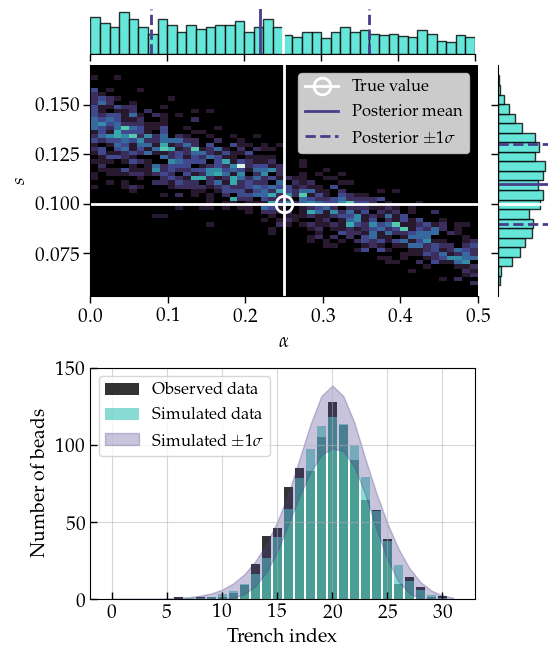

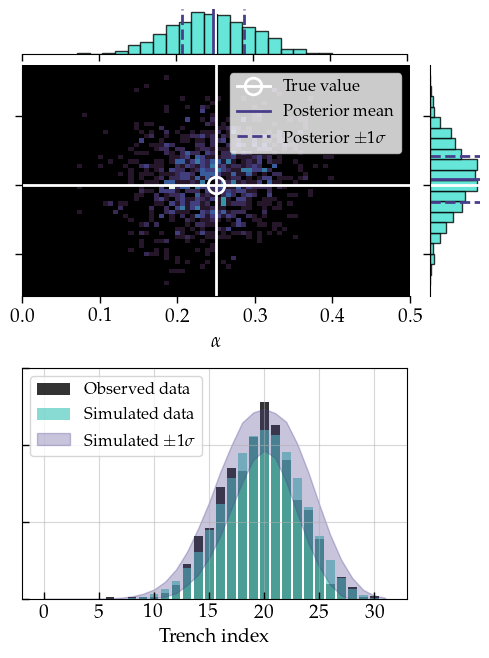

In [ ]:

# Plot results for two selected cases
res_2 = get_ABC_results(results_2, its)
accepted_samples, weights, s_samples, alpha_samples, alpha_mean, alpha_std, s_mean, s_std, y_i, sim_std, sim_std_avg, ABC_its = res_2.iloc[0]
fig, ax = joint_plotter(s_samples, alpha_samples, s_mean, s_std, alpha_mean, alpha_std, weights, 'mako', 'white', 'darkslateblue', [40, 22])
ax.set_facecolor('black')

true_counts = vec_dalton_simulator(n_rows, n_cols, n_beads, 0.25, 0.1, disable=True, seed=19)
simulated_counts = np.mean(y_i, axis=0)

ax_bar = fig.add_axes([0.125, -0.9, 0.77, 0.77])
ax_bar = dist_data_plotter(ax_bar, true_counts, simulated_counts, sim_std, 32)
ax_bar.set_ylim(0, 150)
# fig.savefig('figs/dalton_ABC_summary_comparison_left.pdf', bbox_inches='tight')

res_4 = get_ABC_results(results_4, its)
accepted_samples, weights, s_samples, alpha_samples, alpha_mean, alpha_std, s_mean, s_std, y_i, sim_std, sim_std_avg, ABC_its = res_4.iloc[0]
fig, ax = joint_plotter(s_samples, alpha_samples, s_mean, s_std, alpha_mean, alpha_std, weights, 'mako', 'white', 'darkslateblue', [20, 20])
ax.set_facecolor('black')
ax.set_ylabel('')
ax.set_yticklabels([])

simulated_counts = np.mean(y_i, axis=0)

ax_bar = fig.add_axes([0.125, -0.9, 0.77, 0.77])
ax_bar = dist_data_plotter(ax_bar, true_counts, simulated_counts, sim_std, 32)
ax_bar.set_ylim(0, 150)
ax_bar.set_ylabel('')
ax_bar.set_yticklabels([])
# fig.savefig('figs/dalton_ABC_summary_comparison_right.pdf', bbox_inches='tight')

plt.show()


## **Training Neural Network**

In [ ]:

# Standardize and train MLP regressor
scaler_Y = StandardScaler()

X = training_data.reshape(-1, n_cols) # Input (trenches)
X_norm = X / np.sum(X, axis=1, keepdims=True) # Normalize input
Y = np.array([alpha_train.ravel(), s_train.ravel()]).T # Output (parameters)
Y_scaled = scaler_Y.fit_transform(Y) # Standardize output

# Split data into training and testing sets and train MLP regressor
X_train, X_test, Y_train, Y_test = train_test_split(X_norm, Y_scaled, train_size=0.9, random_state=67)
mlp = MLPRegressor(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=100, early_stopping=True, validation_fraction=0.1, batch_size=256)

mlp.fit(X_train, Y_train)


MLPRegressor(batch_size=256, early_stopping=True)

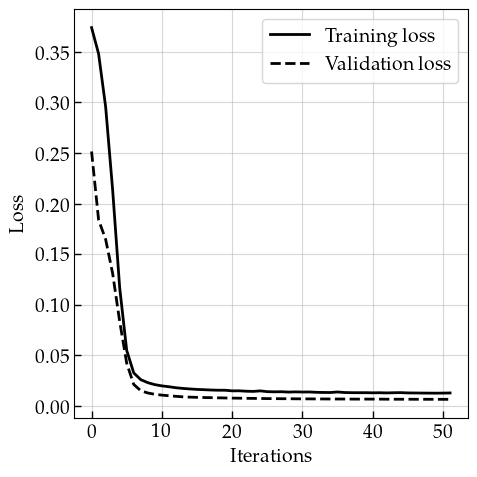

Mean Squared Error on test set: alpha: 0.000489, s: 0.000031
Predicted alpha and s from NN: alpha = 0.250366, s = 0.103385 


In [ ]:

# Retrieve training history
training_loss = mlp.loss_curve_
validation_scores = mlp.validation_scores_
val_loss = [1 - score for score in validation_scores]

# Evaluate the model by computing mean squared error on test set
Y_pred_scaled = mlp.predict(X_test)
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled)
Y_test_inv = scaler_Y.inverse_transform(Y_test)
alpha_err, s_err = np.mean((Y_test_inv - Y_pred) ** 2, axis=0)
print(f'Mean Squared Error on test set: alpha: {alpha_err:.6f}, s: {s_err:.6f}')

its = 100000
y_obs_norm = normalize_trenches(y_obs) # Normalize observed data
sample = mlp.predict(y_obs_norm.reshape(1, -1)) # Predict parameters from observed data
alpha_pred, s_pred = scaler_Y.inverse_transform(sample)[0]
print(f'Predicted alpha and s from NN: alpha = {alpha_pred:.6f}, s = {s_pred:.6f} ')


In [ ]:

# # Run ABC using NN predictions
# results_NN_1 = ABC(y_obs, its, summary_choice='mean', h='cal', h_quantile=0.01, cal_its=1000, s_pred=s_pred, s_error=s_err)
results_NN_2 = ABC(y_obs, its, summary_choice='all', h='cal', h_quantile=0.01, cal_its=1000, s_pred=s_pred, s_error=s_err)


Running ABC iterations: 100%|██████████| 100000/100000 [03:06<00:00, 535.12it/s]


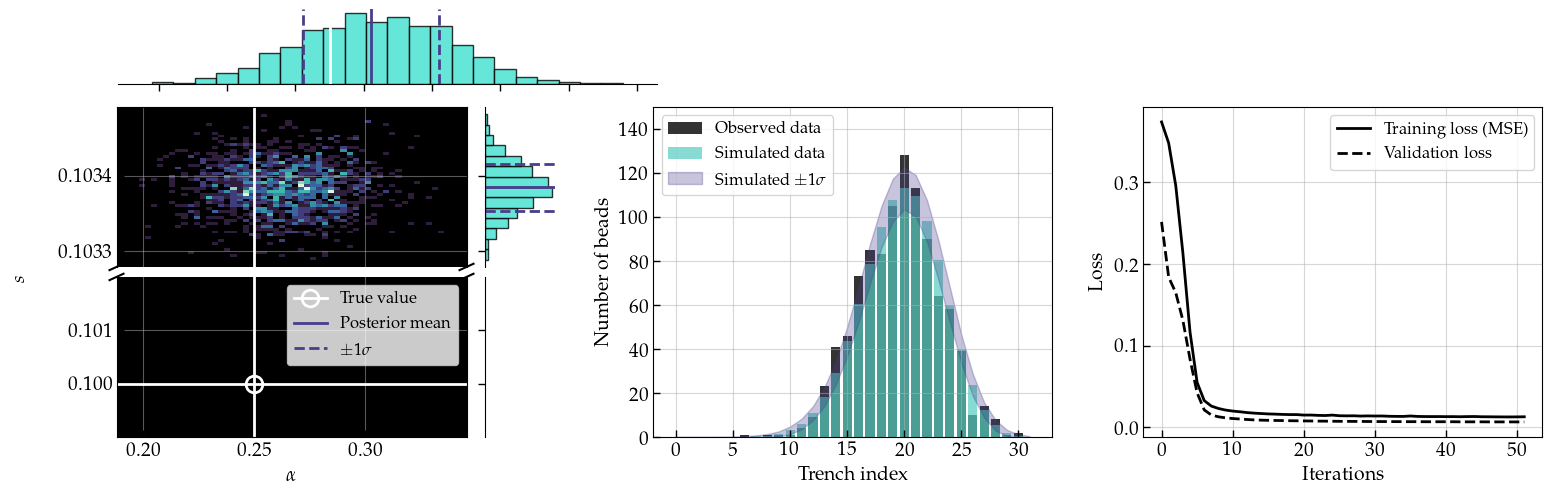

In [ ]:

# Plot results for ABC with NN predictions
res_2 = get_ABC_results(results_NN_2, its)
accepted_samples, weights, s_samples, alpha_samples, alpha_mean, alpha_std, s_mean, s_std, y_i, sim_std, sim_std_avg, ABC_its = res_2.iloc[0]
fig, ax = joint_plotter(s_samples, alpha_samples, s_mean, s_std, alpha_mean, alpha_std, weights, 'mako', 'white', 'darkslateblue', [22, 14], figsize=(7, 5), broken=True)
ax[0].set_facecolor('black')
ax[1].set_facecolor('black')

y_i_NN = np.array(results_NN_2['y_i'])
simulated_counts = np.mean(y_i_NN, axis=0)

ax_bar = fig.add_axes([0.89, 0.21, 0.57, 0.66])
ax_bar = dist_data_plotter(ax_bar, true_counts, simulated_counts, sim_std, 32)
ax_bar.set_ylim(0, 150)
# fig.savefig('figs/dalton_ABC_NN_summary_comparison_right.pdf', bbox_inches='tight')

ax_loss = fig.add_axes([1.59, 0.21, 0.57, 0.66])
ax_loss.plot(val_loss, linewidth=2, color='k')
ax_loss.plot(training_loss, linewidth=2, color='k', linestyle='--')
ax_loss.legend(['Training loss (MSE)', 'Validation loss'], fontsize=12)
ax_loss.set_xlabel('Iterations')
ax_loss.set_ylabel('Loss')
ax_loss.grid(True, linestyle='-', alpha=0.5)

# plt.savefig('figs/dalton_ABC_NN_summary_comparison_combined.pdf', bbox_inches='tight')
plt.show()


## **Chain of Transformers**

In [ ]:

# Perform multiple posterior transformations and ABC
N_transformations = 200
rng = np.random.default_rng(67)
its = 1000 # Number of ABC iterations per transformation

# Store results
transformation_results = {
    'alpha_samples': [],
    'alpha_mean': [],
    'alpha_std': [],
    's_mean': [],
    's_std': [],
    'accepted_samples': []
}
alpha_mean_trans = None
alpha_std_trans = None
for i in tqdm(range(N_transformations), desc='Performing posterior chain transformations'):
    exp_idx = rng.integers(0, n_trials) # Randomly select an experiment
    y_obs_trans = board_data[exp_idx] # Observed data for the selected experiment
    pred_trans = mlp.predict(normalize_trenches(y_obs_trans).reshape(1, -1)) # Predict parameters from observed data
    _, s_pred_trans = scaler_Y.inverse_transform(pred_trans)[0] # Predicted s from NN

    # Run ABC for the transformed observed data
    trans_result = ABC(y_obs_trans, its, summary_choice='all', h='cal', h_quantile=0.01, cal_its=1000, s_pred=s_pred_trans, s_error=s_err, alpha_mean=alpha_mean_trans, alpha_error=alpha_std_trans, disable=True)
    
    # Retrieve and store results
    s_samples_trans = np.array(trans_result['s'])
    alpha_samples_trans = np.array(trans_result['alpha'])
    alpha_mean_trans = np.mean(alpha_samples_trans)
    alpha_std_trans = np.std(alpha_samples_trans)
    s_mean_trans = np.mean(s_samples_trans)
    s_std_trans = np.std(s_samples_trans)
    transformation_results['alpha_samples'].append(alpha_samples_trans)
    transformation_results['alpha_mean'].append(alpha_mean_trans)
    transformation_results['alpha_std'].append(alpha_std_trans)
    transformation_results['s_mean'].append(s_mean_trans)
    transformation_results['s_std'].append(s_std_trans)
    transformation_results['accepted_samples'].append(len(alpha_samples_trans))


Performing data transformations and ABC: 100%|██████████| 200/200 [12:50<00:00,  3.85s/it]


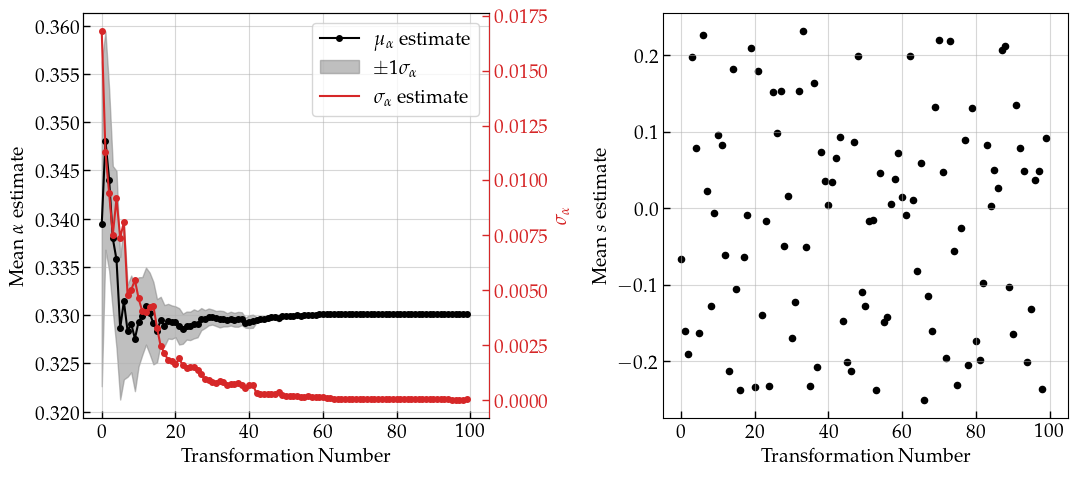

In [ ]:

# Plot transformation results
fig, axs = plt.subplots(1, 2, figsize=(11, 5))
axs[0].plot(np.arange(N_transformations)[:100], transformation_results['alpha_mean'][:100], color='k', marker='o', label=r'$\mu_\alpha$ estimate', markersize=4)
axs[0].fill_between(np.arange(N_transformations)[:100],
                    np.array(transformation_results['alpha_mean'][:100]) - np.array(transformation_results['alpha_std'][:100]),
                    np.array(transformation_results['alpha_mean'][:100]) + np.array(transformation_results['alpha_std'][:100]),
                    color='gray', alpha=0.5, label=r'$\pm 1\sigma_\alpha$')
axs[0].plot([], [], color='tab:red', label=r'$\sigma_\alpha$ estimate')
axs[0].legend()
axs[0].set_xlim(-5, 105)

# Create secondary y-axis for alpha std
ax2 = axs[0].twinx()
ax2.tick_params(color='tab:red', labelcolor='tab:red')
ax2.spines['right'].set_color('tab:red')
ax2.plot(np.arange(N_transformations)[:100], transformation_results['alpha_std'][:100], color='tab:red', marker='o', markersize=4)
ax2.set_ylabel(r'$\sigma_\alpha$', color='tab:red')

# Plot s mean estimates
axs[1].scatter(np.arange(N_transformations)[:100], transformation_results['s_mean'][:100], color='k', s=20)
axs[0].set_ylabel(r'Mean $\alpha$ estimate')
axs[1].set_ylabel(r'Mean $s$ estimate')
axs[0].set_xlabel('Transformation Number')
axs[1].set_xlabel('Transformation Number')
axs[0].grid(True, linestyle='-', alpha=0.5)
axs[1].grid(True, linestyle='-', alpha=0.5)
axs[1].set_xlim(-5, 105)

plt.tight_layout()
# plt.savefig('figs/dalton_ABC_transformation_estimates.pdf', bbox_inches='tight')
plt.show()


---